# **Model CRNN menggunakan 20 segmentasi**


In [1]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

In [ ]:
DATA_PATH = "data_20_segmen.json"

In [4]:
def load_dataset(file_path):
    with open(file_path, "r") as file:
        dataset = json.load(file)
    
    features = np.array(dataset["mfcc"])
    labels = np.array(dataset["labels"])
    genre_mapping = dataset.get("mapping", {})
    
    return features, labels, genre_mapping

In [5]:
def split_dataset(train_ratio, val_ratio, test_ratio):
    X, y, genre_mapping = load_dataset(DATA_PATH)
    
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1 - train_ratio), random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)
    
    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]
    
    return X_train, X_val, X_test, y_train, y_val, y_test, genre_mapping

In [6]:
def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        
        keras.layers.Conv2D(32, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        
        keras.layers.Conv2D(32, (2, 2), activation='relu'),
        keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'),
        keras.layers.BatchNormalization(),
        
        keras.layers.Reshape((-1, 32)),
        
        keras.layers.LSTM(64, return_sequences=True),
        keras.layers.LSTM(64),
        
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        
        keras.layers.Dense(10, activation='softmax')
    ])
    
    return model

In [7]:
def plot_history(history, ratio):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].plot(history.history["accuracy"], label="Akurasi Pelatihan")
    axes[0].plot(history.history["val_accuracy"], label="Akurasi Validasi")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend(loc="lower right")
    axes[0].set_title(f"Akurasi Model 10 Segmen - {ratio}")
    
    axes[1].plot(history.history["loss"], label="Loss Pelatihan")
    axes[1].plot(history.history["val_loss"], label="Loss Validasi")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(loc="upper right")
    axes[1].set_title(f"Model Loss 10 Segmen - {ratio}")
    
    plt.tight_layout()
    plt.show()


def evaluate_performance(model, X_test, y_test, genre_mapping, ratio):
    test_predictions = model.predict(X_test)
    test_predicted_labels = np.argmax(test_predictions, axis=1)
    
    test_conf_matrix = confusion_matrix(y_test, test_predicted_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=genre_mapping, yticklabels=genre_mapping)
    plt.title(f'Confusion Matrix 10 Segmen - {ratio}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()
    
    report_dict = classification_report(y_test, test_predicted_labels, target_names=genre_mapping, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df = report_df.mul(100).round(2)
    
    plt.figure(figsize=(6, 10))
    sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Classification Report 10 Segmen - {ratio}")
    plt.xlabel("Metrics")
    plt.ylabel("Class")
    plt.show()



Evaluating for Train 60.0%, Val 20.0%, Test 20.0%...



c:\Users\Arma Rizki\OneDrive - UGM 365\Documents\TUGAS AKHIR\skripsi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 63, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 4, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 2, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 2, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 1, 32)      │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 1, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,746 (299.79 KB)

 Trainable params: 76,554 (299.04 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.3000 - loss: 2.0224 - val_accuracy: 0.4920 - val_loss: 1.4191
Epoch 2/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4888 - loss: 1.4367 - val_accuracy: 0.5719 - val_loss: 1.2060
Epoch 3/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5536 - loss: 1.2616 - val_accuracy: 0.6207 - val_loss: 1.0967
Epoch 4/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5890 - loss: 1.1651 - val_accuracy: 0.6335 - val_loss: 1.0439
Epoch 5/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6253 - loss: 1.0848 - val_accuracy: 0.6526 - val_loss: 0.9878
Epoch 6/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.6426 - loss: 1.0364 - val_accuracy: 0.6594 - val_loss: 0.9569
Epoch 7/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.6610 - loss: 0.9812 - val_accuracy: 0.6852 - val_loss: 0.9039
Epoch 8/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6757 - loss: 0.9499 - 

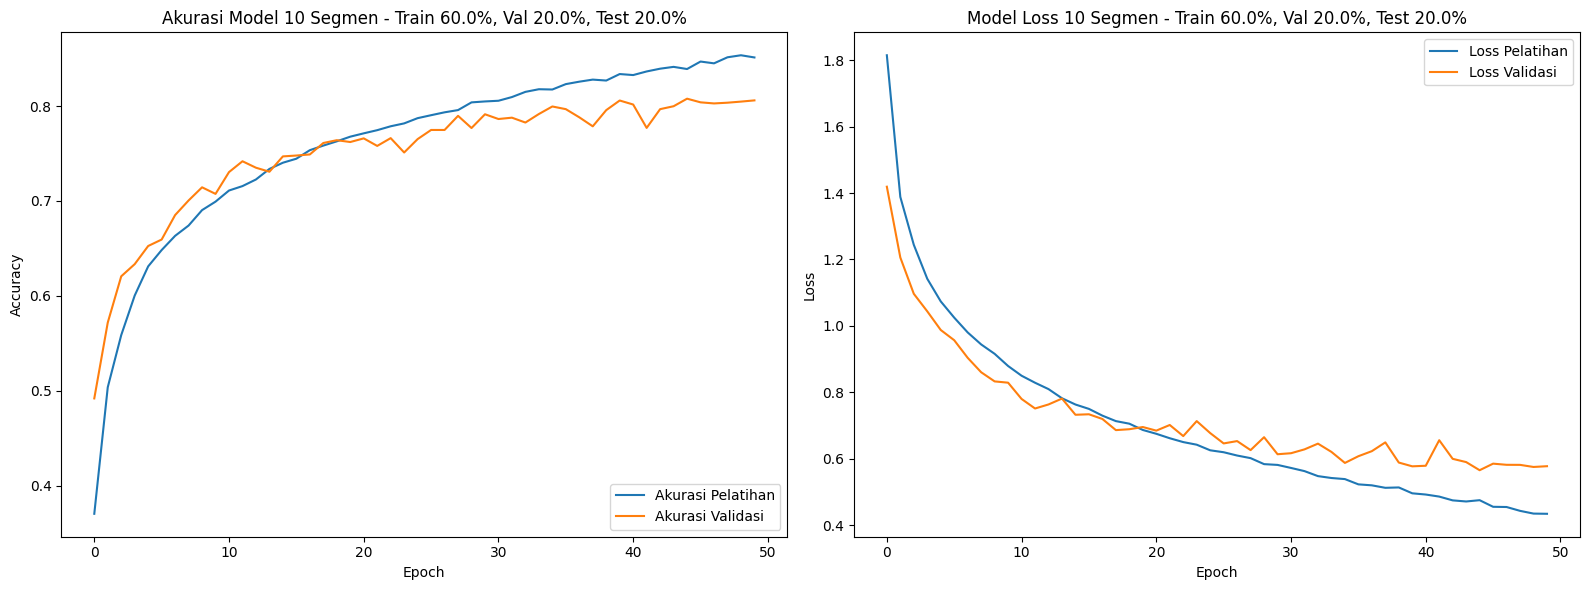

244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


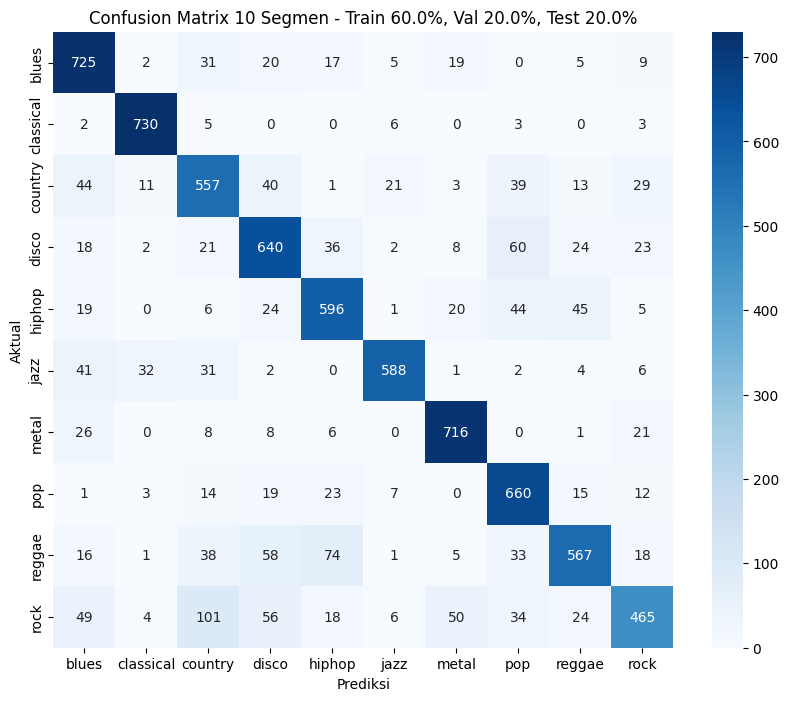

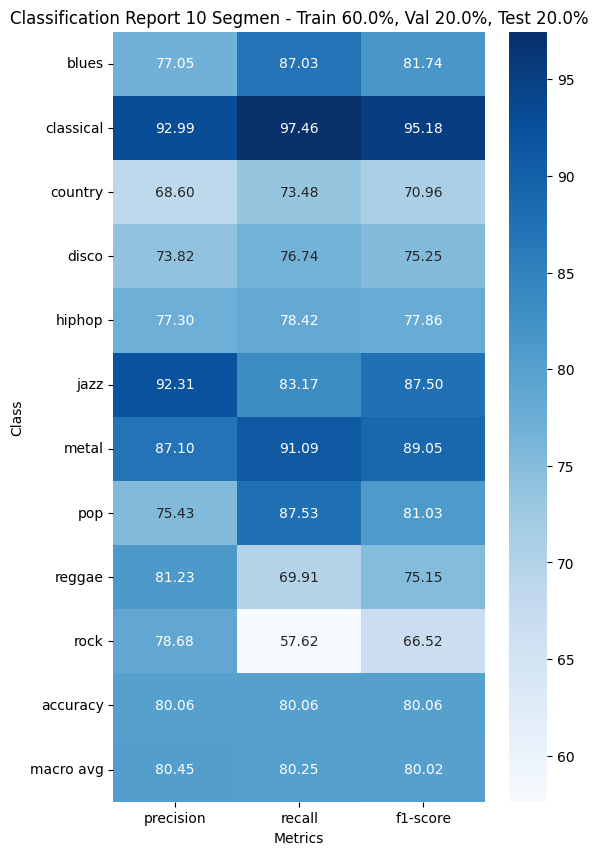


Evaluating for Train 70.0%, Val 15.0%, Test 15.0%...



c:\Users\Arma Rizki\OneDrive - UGM 365\Documents\TUGAS AKHIR\skripsi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 63, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 4, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 2, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 2, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 1, 32)      │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 1, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,746 (299.79 KB)

 Trainable params: 76,554 (299.04 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.2929 - loss: 1.9904 - val_accuracy: 0.5257 - val_loss: 1.3115
Epoch 2/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.5128 - loss: 1.3605 - val_accuracy: 0.5933 - val_loss: 1.1395
Epoch 3/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.5706 - loss: 1.2062 - val_accuracy: 0.6345 - val_loss: 1.0295
Epoch 4/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6054 - loss: 1.1287 - val_accuracy: 0.6628 - val_loss: 0.9647
Epoch 5/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6344 - loss: 1.0462 - val_accuracy: 0.6642 - val_loss: 0.9426
Epoch 6/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6532 - loss: 1.0078 - val_accuracy: 0.6897 - val_loss: 0.8873
Epoch 7/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6643 - loss: 0.9631 - val_accuracy: 0.6960 - val_loss: 0.8687
Epoch 8/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6780 - loss: 0.9287 - 

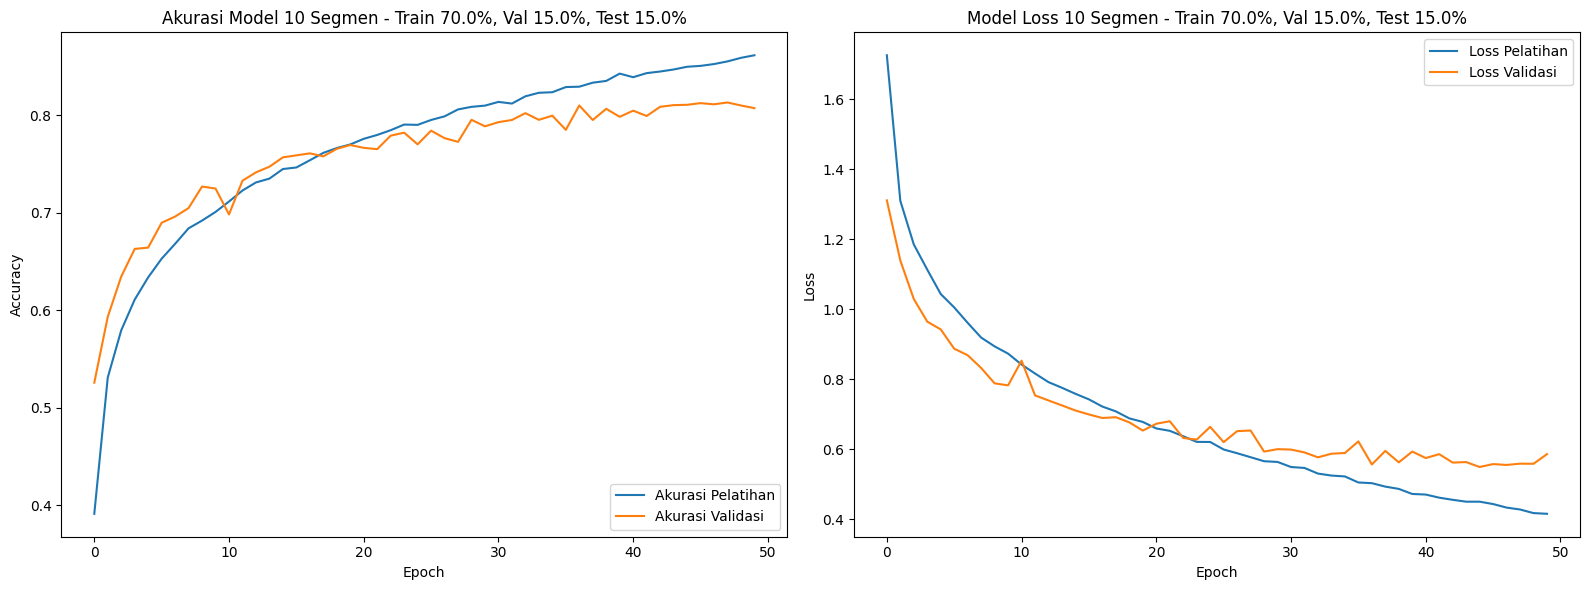

183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


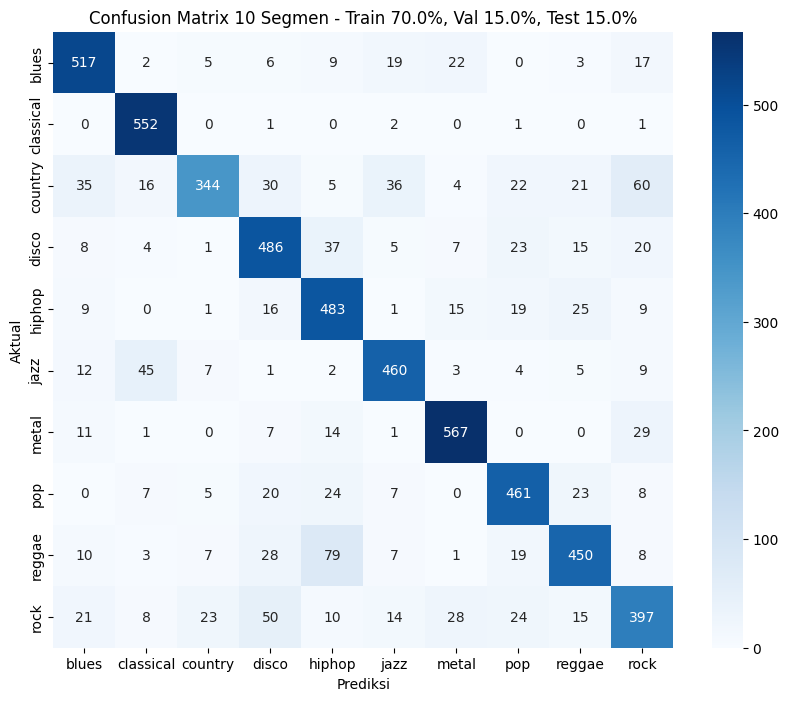

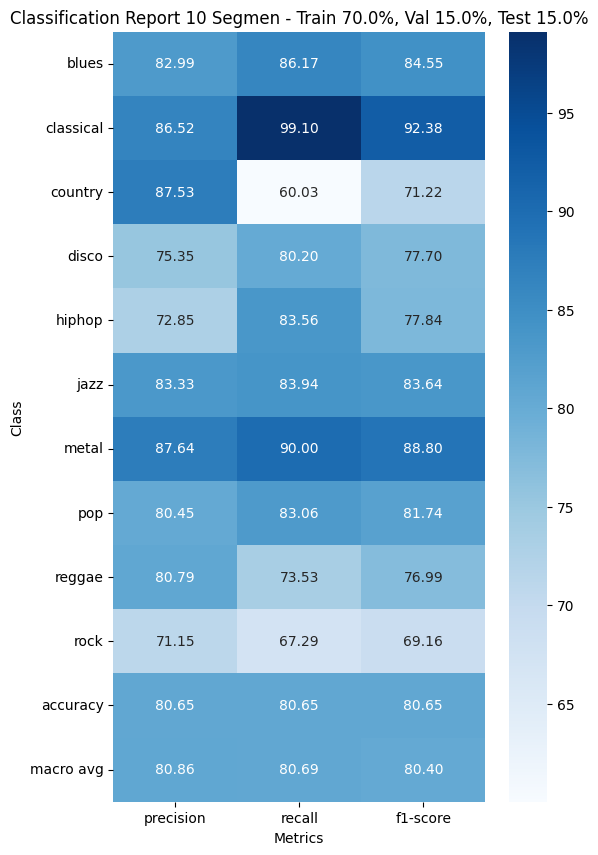


Evaluating for Train 80.0%, Val 10.0%, Test 10.0%...



c:\Users\Arma Rizki\OneDrive - UGM 365\Documents\TUGAS AKHIR\skripsi\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 63, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 4, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 2, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 2, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 1, 32)      │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 1, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 7, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,746 (299.79 KB)

 Trainable params: 76,554 (299.04 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.3178 - loss: 1.9666 - val_accuracy: 0.5276 - val_loss: 1.3283
Epoch 2/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.5299 - loss: 1.3306 - val_accuracy: 0.6207 - val_loss: 1.1090
Epoch 3/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.5859 - loss: 1.1692 - val_accuracy: 0.6325 - val_loss: 1.0688
Epoch 4/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.6349 - loss: 1.0541 - val_accuracy: 0.6661 - val_loss: 0.9775
Epoch 5/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.6617 - loss: 0.9973 - val_accuracy: 0.6979 - val_loss: 0.8862
Epoch 6/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.6766 - loss: 0.9428 - val_accuracy: 0.6871 - val_loss: 0.8999
Epoch 7/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6937 - loss: 0.8972 - val_accuracy: 0.7012 - val_loss: 0.8611
Epoch 8/50
975/975 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7077 - loss: 0.8673 - 

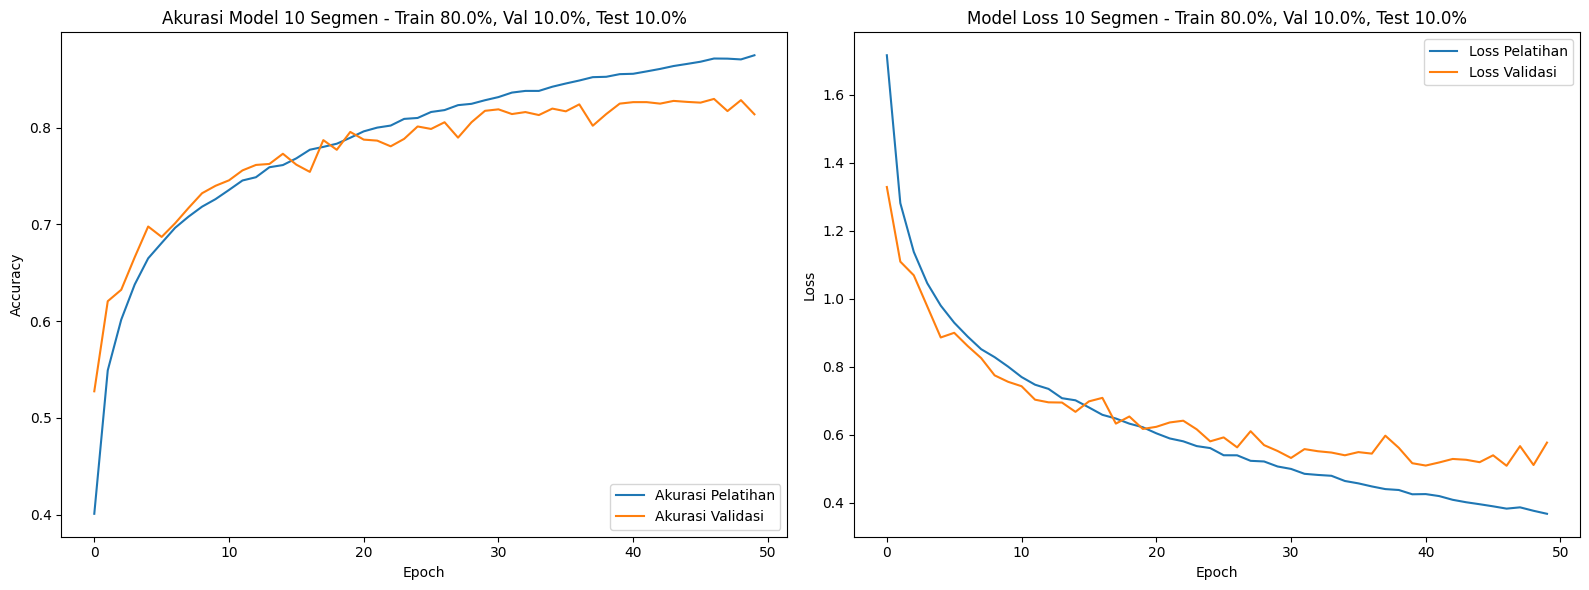

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


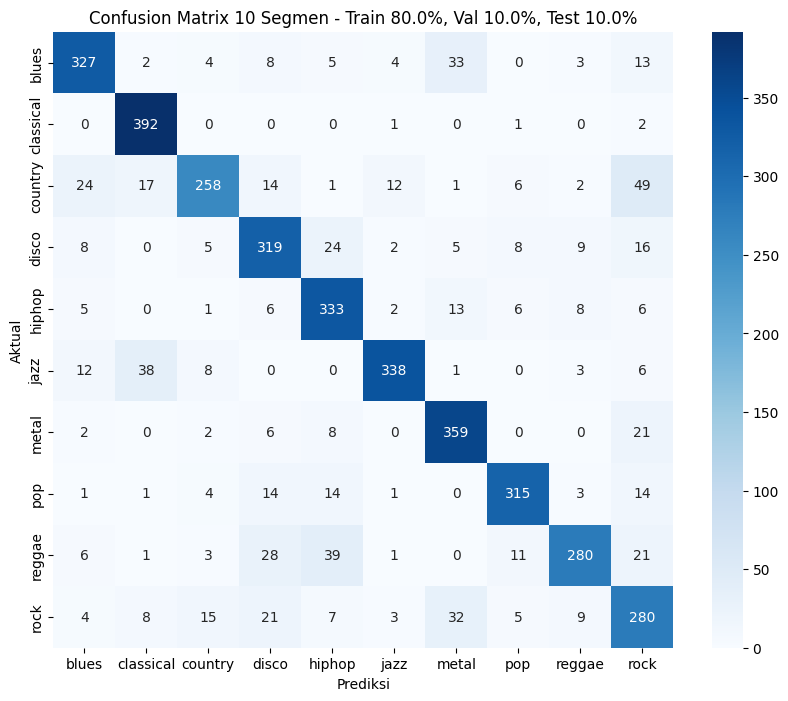

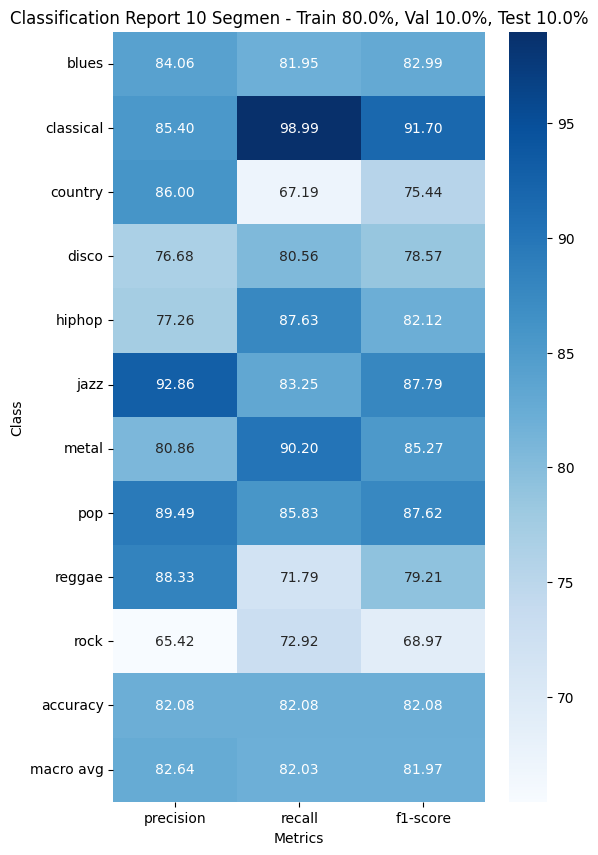

In [8]:
if __name__ == "__main__":
    split_ratios = [
        (0.6, 0.2, 0.2),
        (0.7, 0.15, 0.15),
        (0.8, 0.1, 0.1)
    ]
    
    for train_ratio, val_ratio, test_ratio in split_ratios:
        ratio_str = f"Train {train_ratio * 100}%, Val {val_ratio * 100}%, Test {test_ratio * 100}%"
        print(f"\nEvaluating for {ratio_str}...\n")
        
        X_train, X_val, X_test, y_train, y_val, y_test, genre_mapping = split_dataset(train_ratio, val_ratio, test_ratio)
        input_dim = (X_train.shape[1], X_train.shape[2], 1)
        
        model = create_model(input_dim)
        optimizer = keras.optimizers.Adam(learning_rate=0.0001)
        model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        model.summary()
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=32, epochs=50)
        plot_history(history, ratio_str)
        evaluate_performance(model, X_test, y_test, genre_mapping, ratio_str)